# LIDC-IDRI Extension

_Author&nbsp;• Saam Nazempour  |  MPhil Data Intensive Science, University of Cambridge_

This notebook **extends** the pipeline to the LIDC-IRDI dataset, with deeper feature-selection and modelling experiments.  
It guides the reader through:

1. **Dataset & ROI Preparation** – filtering the XMLS and creating 284 3D tumours volumes from the 107 'good' patients
2. **Radiomic Feature Extraction** – 3D PyRadiomics, 107 descriptors per nodule (including shape features)
4. **Advanced Feature Selection** – **RFE** vs **Boruta** atop KW + correlation filtering (27 vs 19 features selected) 
5. **ML Classifier Benchmarking** – RF, XGB, SVM, LogReg (± SMOTE)
6. **Model Discrimination** – SHAP values & 1000-seed stability checks  


In [1]:
# === Core Libraries ===
import os
import sys
import glob
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Image and DICOM Processing ===
import pydicom
import SimpleITK as sitk
from skimage.draw import polygon
from pathlib import Path

# === LIDC Tools ===
import pylidc as pl
import xml.etree.ElementTree as ET

# === Radiomics ===
from radiomics import featureextractor

# === Statistics & Testing ===
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pingouin as pg

# === ML and Feature Selection ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFECV
from boruta import BorutaPy

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

# === Progress Bar ===
from tqdm import tqdm

# === Plotting Utils ===
from matplotlib_venn import venn2

# === Custom Project Functions ===
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(src_path)

from Extension import (
    plot_patient_tumours_3d,
    assign_tumour_ids_by_overlap,
    bootstrap_ci,
    get_friendly_feature_names,
    parse_xml_rois,
    build_3d_volumes_from_rois,
    extract_radiomic_features,
    merge_radiomics_with_labels,
    select_features_kw_fdr,
    remove_correlated_features,
    run_rfecv,
    run_boruta,
    train_test_with_smote,
    evaluate_pipeline,
    cross_val_auc,
    build_xgb_model,
    build_logreg_pipeline,
    build_rf_pipeline,
    build_logreg_pipeline,
    build_svm_pipeline,
    build_xgb_model,
    fit_and_evaluate_model,
    plot_bootstrap_metrics_bars,
    plot_feature_selection_venn,
    plot_shap_rank_stability,
    plot_shap_summary_and_bar,
    compute_shap_rank_stability,
    print_metric_table
)


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1) Dataset Preparation

This section prepares the LIDC-IDRI dataset for 3D radiomics analysis:

1. **DICOM Slice Visualisation**  
   Example axial, coronal, and sagittal views are shown for orientation.

2. **XML Parsing & Matching**  
   Annotation XMLs are parsed and matched to DICOM scans by patient ID and nodule coordinates.

3. **Filtering**  
   We retain only nodules with:
   - ≥ 3 ROI annotations
   - Malignancy labels of 1, 2, or 3 (excluding label 0)

4. **3D Volume Construction**  
   Valid ROIs are clustered into 3D tumour volumes using a custom overlap-based algorithm.

> Final dataset: 284 nodules across 107 patients.


1. DICOM slice visualisation

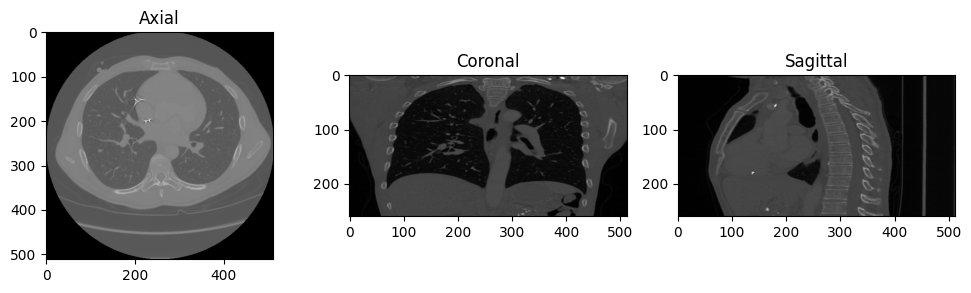

In [2]:
# Define path
dicom_folder = Path("../data/LIDC_Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI/LIDC-IDRI-0068/01-01-2000-NA-CT CHEST W CONT-80168/4.000000-Recon 3 CT CHEST-26125")

# Load and sort DICOM slices
slices = [pydicom.dcmread(p) for p in dicom_folder.glob("*.dcm")]
slices = sorted(slices, key=lambda s: int(s.InstanceNumber))

# Stack to form volume
volume = np.stack([s.pixel_array for s in slices]).astype(np.int16)

# Plot center slices
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(volume[volume.shape[0] // 2], cmap="gray")
axes[0].set_title("Axial")
axes[1].imshow(volume[:, volume.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[2].imshow(volume[:, :, volume.shape[2] // 2], cmap="gray")
axes[2].set_title("Sagittal")

plt.tight_layout()
plt.savefig("../plots_extension/misc/Example_slices.png", dpi=400)
plt.show()


2. Parse XMLs and connect to DICOM files

In [3]:
# --- Setup ---
base_dir = "../data/LIDC_Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI"
ns = {"lidc": "http://www.nih.gov"}
roi_records = []

all_patients = sorted(os.listdir(base_dir))
print(" Total patient folders found:", len(all_patients))

# Tracking
missing_xml_patients = []
malformed_roi_patients = set()
parsed_patients = set()

# --- Traverse each patient folder ---
for patient_id in all_patients:
    patient_path = os.path.join(base_dir, patient_id)
    if not os.path.isdir(patient_path):
        continue

    # Find XML files
    xml_files = []
    for root_dir, _, files in os.walk(patient_path):
        xml_files.extend([
            os.path.join(root_dir, file)
            for file in files if file.endswith(".xml")
        ])

    if not xml_files:
        missing_xml_patients.append(patient_id)
        continue

    roi_found = False
    for xml_file in xml_files:
        rois, found = parse_xml_rois(xml_file, ns, patient_id)
        if rois:
            roi_records.extend(rois)
        if found:
            roi_found = True
        else:
            malformed_roi_patients.add(patient_id)

    if roi_found:
        parsed_patients.add(patient_id)

# --- Final DataFrame ---
df_roi = pd.DataFrame(roi_records)
unique_patients_in_df = df_roi["PatientID"].nunique()

# --- Summary ---
print("\n df_roi shape:", df_roi.shape)
print(" Unique PatientIDs in df_roi:", unique_patients_in_df)
print(" Patients with no XML:", len(missing_xml_patients))
print(" Patients with malformed ROIs only:", len(malformed_roi_patients))
print(" Total patients with parsed XML:", len(parsed_patients))
print(" Example patients with no XML:", missing_xml_patients[:5])
print(" Example patients with malformed ROIs:", list(malformed_roi_patients)[:5])


 Total patient folders found: 158

 df_roi shape: (9068, 5)
 Unique PatientIDs in df_roi: 157
 Patients with no XML: 0
 Patients with malformed ROIs only: 114
 Total patients with parsed XML: 157
 Example patients with no XML: []
 Example patients with malformed ROIs: ['LIDC-IDRI-0173', 'LIDC-IDRI-0068', 'LIDC-IDRI-0072', 'LIDC-IDRI-0232', 'LIDC-IDRI-0283']


3. Filtering

In [4]:
# --- Load diagnosis labels ---
df_diag = pd.read_excel("../data/LIDC_Extension/tcia-diagnosis-data-2012-04-20.xls")

# Standardize PatientID format
df_diag.rename(columns={df_diag.columns[0]: "PatientID"}, inplace=True)
df_diag["PatientID"] = (
    df_diag["PatientID"]
    .str.replace("LIDC-IDRI-", "", regex=False)
    .astype(str)
    .str.zfill(4)
)
df_diag["PatientID"] = "LIDC-IDRI-" + df_diag["PatientID"]

# Keep only necessary columns
df_diag = df_diag[["PatientID", df_diag.columns[1]]]
df_diag.columns = ["PatientID", "Diagnosis"]

# Assign binary label: 1 = malignant (2 or 3), 0 = benign (1)
df_diag["Label"] = df_diag["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)

# --- Merge diagnosis into ROI DataFrame ---
df_roi_labeled = df_roi.merge(df_diag, on="PatientID", how="left")
print(" ROI + Diagnosis merged shape:", df_roi_labeled.shape)
print(" Missing labels:", df_roi_labeled["Label"].isna().sum())

# --- Count ROIs per Patient + Nodule ---
roi_counts = df_roi_labeled.groupby(["PatientID", "NoduleID"]).size().reset_index(name="NumROIs")
df_roi_final = df_roi_labeled.merge(roi_counts, on=["PatientID", "NoduleID"], how="left")

# --- Load metadata for filtering ---
df_main = pd.read_csv("../data/LIDC_Extension/csv/MAIN_DATAFRAME_PATIENT_COORDS_LABEL.csv")

# Filter: retain nodules with ≥3 ROIs and known diagnosis
df_good = df_main[(df_main["NumROIs"] >= 3) & (df_main["Diagnosis"].isin([1, 2, 3]))]
df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)

print(" Good nodules retained:", df_good.shape)


 ROI + Diagnosis merged shape: (9068, 7)
 Missing labels: 0
 Good nodules retained: (6830, 8)


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_32313/2366058527.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)


4. 3D Tumour Volume Creation

In [5]:
# Load filtered and labeled good nodules
df_good = pd.read_csv("../data/LIDC_Extension/csv/MAIN_DATAFRAME_PATIENT_GOOD_COORDS_LABEL.csv")

# Assign TumourIDs based on overlapping coordinates
df_good_clean = assign_tumour_ids_by_overlap(df_good)

Assigning TumourIDs: 100%|██████████| 107/107 [00:03<00:00, 29.20it/s]


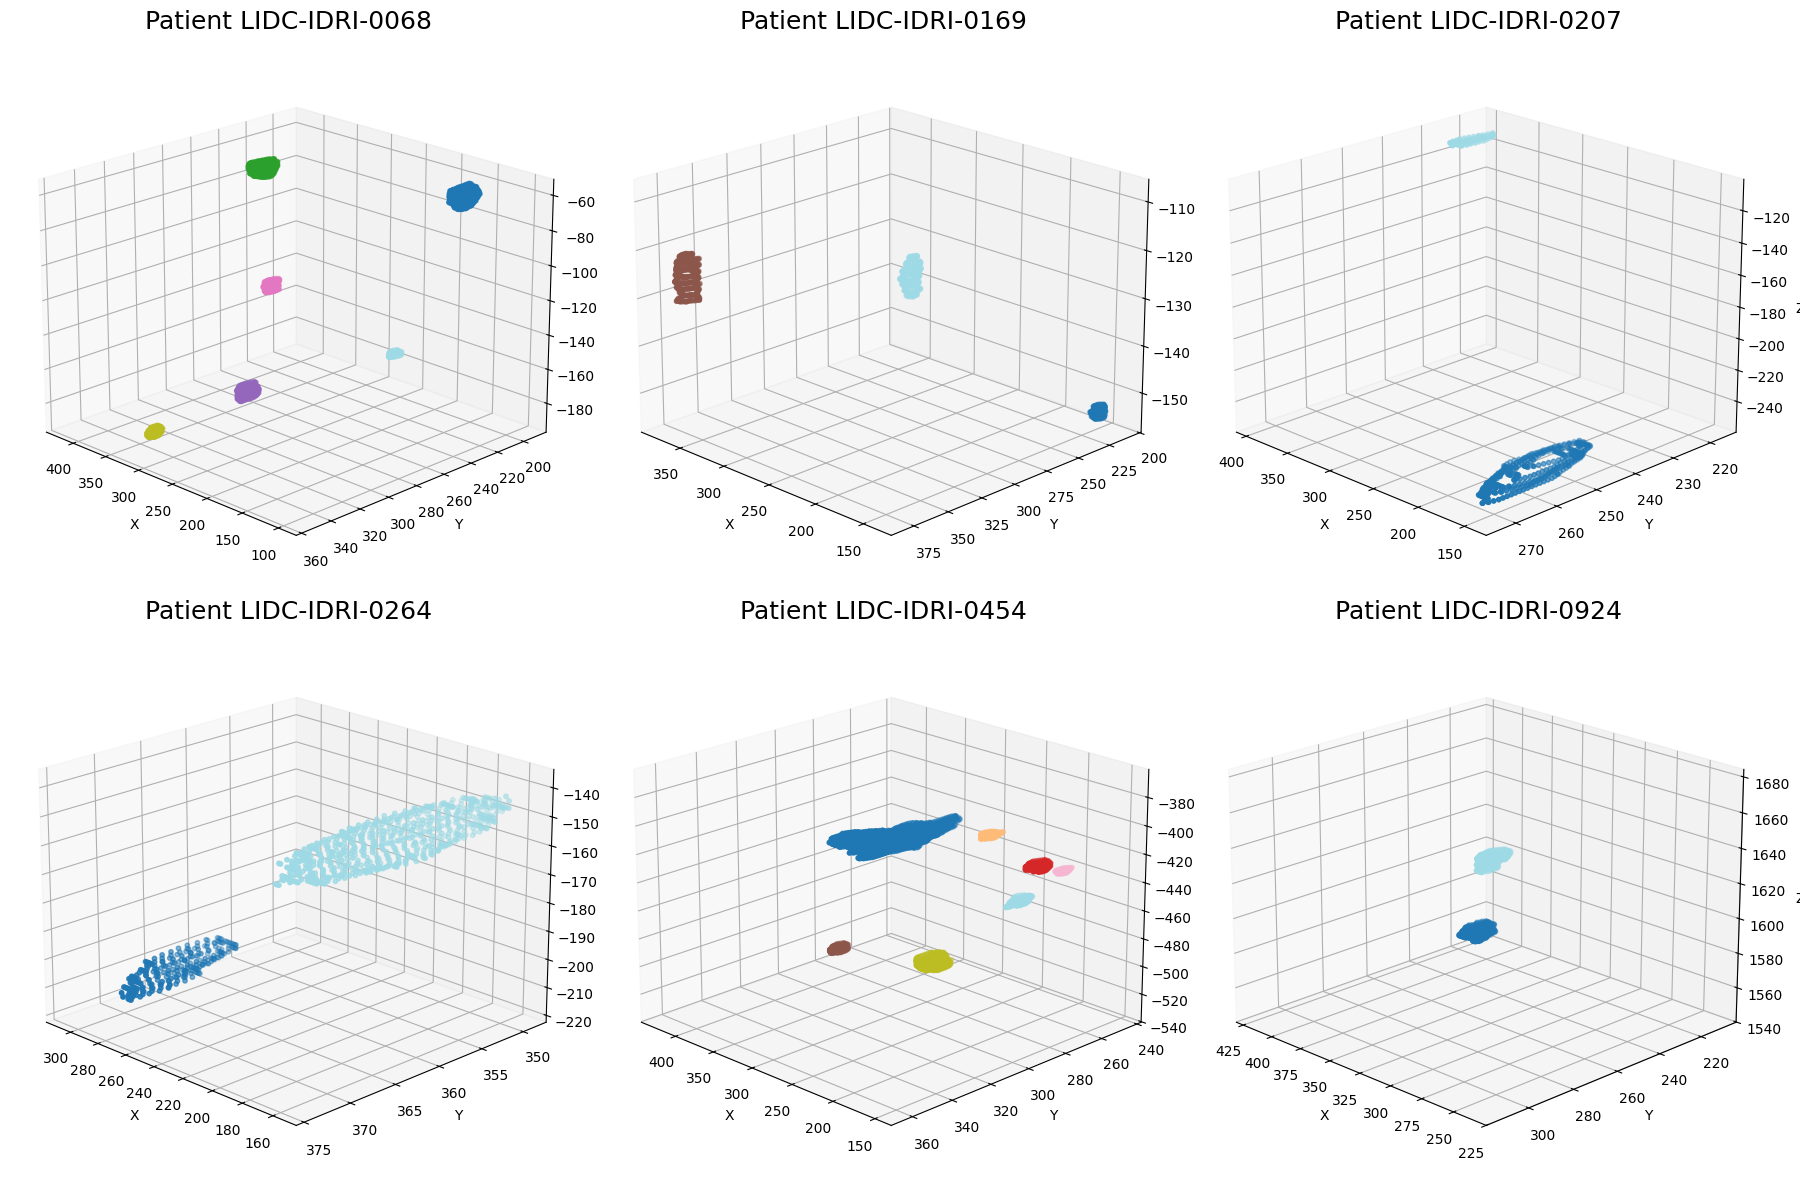

In [6]:
# Visualise 3D masks for 6 representative patients
fig = plt.figure(figsize=(18, 12))  # 2x3 grid
patient_ids = df_good_clean["PatientID"].unique()
indices = [0, 20, 40, 60, 80, 100]

for idx, i in enumerate(indices):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    pid = patient_ids[i]
    ax.set_title(f"Patient {pid}", fontsize=18)
    plot_patient_tumours_3d(df_good_clean, pid, ax=ax)  # <- Function from src

plt.tight_layout()
plt.savefig("../plots_extension/misc/Example_3Dtumours_2x3_grid.png", dpi=400)
plt.show()

In [7]:
run = input("Create 3D volumes? (y/n): ")

if run.lower() != 'y':
    print(" Exiting without creating 3D volumes.")
else:
    build_3d_volumes_from_rois(
        df_good_clean=df_good_clean,
        dicom_root="../data/LIDC_Extension/DICOM_DATA_120_PATIENTS/New_manifest/manifest-1747751008571/LIDC-IDRI",
        output_path="../data/LIDC_Extension/volume_results_alternative_run.pkl"
    )

 Exiting without creating 3D volumes.


## 2) Radiomic Extraction

We extract 107 original radiomic features from the 3D tumour volumes using PyRadiomics.  
These include first-order, shape, and texture descriptors.

After extraction, we:
- Append the corresponding malignancy labels  
- Convert categorical columns to numeric format for downstream analysis

> Output: a clean radiomics feature matrix ready for statistical testing and modelling.


In [8]:
with open("../data/LIDC_Extension/volume_results.pkl", "rb") as f:
    volume_results = pickle.load(f)

In [9]:
df_radiomics = extract_radiomic_features(volume_results)

# Uncomment to save the DataFrame to CSV
# df_radiomics.to_csv("../data/LIDC_Extension/csv/All_radiomic_features_3D.csv", index=False)
# print(" Saved radiomics features to All_radiomic_features_3D.csv")

Extracting radiomics:   1%|▏         | 4/284 [00:00<00:45,  6.16it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   2%|▏         | 7/284 [00:01<01:05,  4.22it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   4%|▎         | 10/284 [00:01<00:42,  6.44it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Extracting radiomics:   5%|▌         | 15/284 [00:02<00:42,  6.29it/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, 

Append Labels to dataset and make numeric

In [10]:
df_radiomics_labeled = merge_radiomics_with_labels(df_radiomics, df_good_clean)

for col in df_radiomics_labeled.columns:
    if df_radiomics_labeled[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        df_radiomics_labeled[col] = df_radiomics_labeled[col].apply(
            lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else x
        )

## 3) Machine Learning Training and Evaluation

This section focuses on building and evaluating classification models to distinguish benign from malignant nodules.

1. **Feature Selection – Part 1**  
   Initial filtering using:
   - Kruskal-Wallis test (with FDR correction)  
   - Correlation thresholding to remove redundancy

2. **Feature Selection – Part 2**  
   Two advanced selectors are applied:
   - **RFE** (27 features)
   - **Boruta** (19 features)

3. **Model Training & Evaluation**  
   We train four classifiers on both feature sets:
   - Random Forest, XGBoost, Logistic Regression, and SVM  
   - Each evaluated on both the original and SMOTE-balanced datasets  
   - Performance metrics are averaged across 5-fold cross-validation

4. **Error Analysis**  
   Standard errors are computed to assess performance stability.

5. **ML Plot**
   Final ML plot comparing the performance of all the above classifiers

> This allows fair comparison of feature selectors and classifiers under balanced vs imbalanced settings.


In [11]:
df_radiomics_labeled = pd.read_csv("../data/LIDC_Extension/csv/All_3D_Radiomics_labelsappended_numeric.csv")

1. Feature Selection Part 1

In [12]:
X_selected, selected_features, pvals_corrected = select_features_kw_fdr(df_radiomics_labeled)
final_features = remove_correlated_features(df_radiomics_labeled, selected_features, pvals_corrected)
X_filtered = df_radiomics_labeled[final_features]
y = df_radiomics_labeled["Label"]

 Selected 70 features out of 107 after FDR correction.


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))


 31 features selected after rm_corr filtering


Feature Selection Part 2

In [13]:
rfe_selected = run_rfecv(X_filtered, y, "../plots_extension/feature_selection_plots/rfecv_accuracy_vs_features_2.png")

 Optimal number of features: 16
 Selected features: ['original_firstorder_Minimum', 'original_firstorder_RootMeanSquared', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_ngtdm_Coarseness', 'original_gldm_SmallDependenceLowGrayLevelEmphasis', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glszm_GrayLevelNonUniformityNormalized', 'original_firstorder_Range', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glcm_JointEntropy', 'original_glcm_Imc1', 'original_gldm_DependenceEntropy', 'original_glszm_GrayLevelNonUniformity', 'original_shape_Elongation', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_shape_SurfaceVolumeRatio']


In [14]:
# --- Inputs (X and y) ---
X = df_radiomics_labeled[final_features].copy()
y = df_radiomics_labeled["Label"].copy()

boruta_selected = run_boruta(X, y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	13
Tentative: 	18
Rejected: 	0
Iteration: 	9 / 100
Confirmed: 	13
Tentative: 	16
Rejected: 	2
Iteration: 	10 / 100
Confirmed: 	13
Tentative: 	16
Rejected: 	2
Iteration: 	11 / 100
Confirmed: 	13
Tentative: 	16
Rejected: 	2
Iteration: 	12 / 100
Confirmed: 	14
Tentative: 	15
Rejected: 	2
Iteration: 	13 / 100
Confirmed: 	14
Tentative: 	14
Rejected: 	3
Iteration: 	14 / 100
Confirmed: 	14
Tentative: 	14
Rejected: 	3
Iteration: 	15 / 100
Confirmed: 	14
Tentative: 	14
Rejected: 	3
Iteration: 	16 / 100
Confirmed: 	15
Tentative: 	13
Rejec

Save these feature sets for reproducability sake

In [15]:
### Load selected features
boruta_selected = pd.read_csv('../data/LIDC_Extension/csv/Boruta_Selected_Features.csv', header=None)
boruta_selected = boruta_selected[0].tolist()
rfecv_selected = pd.read_csv('../data/LIDC_Extension/csv/RFECV_Selected_Features.csv', header=None)
rfe_selected = rfecv_selected[0].tolist()

In [16]:
common = set(boruta_selected) & set(rfe_selected)
only_boruta = set(boruta_selected) - set(rfe_selected)
only_rfe = set(rfe_selected) - set(boruta_selected)

print("\n Common features:", list(common))
print(" Only in Boruta:", list(only_boruta))
print(" Only in RFE:", list(only_rfe))



 Common features: ['original_firstorder_Minimum', 'original_firstorder_RootMeanSquared', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_ngtdm_Coarseness', 'original_glcm_JointEnergy', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glszm_GrayLevelNonUniformityNormalized', 'original_firstorder_Range', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glcm_JointEntropy', 'original_glcm_Imc1', 'original_gldm_DependenceEntropy', 'original_glszm_GrayLevelNonUniformity', 'original_shape_Elongation', 'original_glszm_LowGrayLevelZoneEmphasis', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_shape_SurfaceVolumeRatio']
 Only in Boruta: []
 Only in RFE: ['original_shape_Sphericity', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_gldm_SmallDependenceLowGrayLevelEmphasis', 'original_firstorder_Energy', 'original_shape_Maximum2DDiameterSlice', 'origi

In [17]:
y = df_radiomics_labeled["Label"]
# === RFE PATH ===
X_rfe = df_radiomics_labeled[rfe_selected]
X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = train_test_with_smote(X_rfe, y)

# === Boruta PATH ===
X_boruta = df_radiomics_labeled[boruta_selected]
X_train_b, X_test_b, y_train_b, y_test_b, X_train_b_smote, y_train_b_smote = train_test_with_smote(X_boruta, y)

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


3. Model Training and Evaluation

Random Forest

In [18]:
# === RFE Evaluation ===
cross_val_auc(X_train, y_train)
report_rfe_rf_nosmote = evaluate_pipeline(X_train, y_train, X_test, y_test, report_name="RFE RF No SMOTE")

report_RF_smote = evaluate_pipeline(X_train_smote, y_train_smote, X_test, y_test, report_name="RFE RF SMOTE")

# === Boruta Evaluation ===
cross_val_auc(X_train_b, y_train_b)
report_boruta_rf_nosmote = evaluate_pipeline(X_train_b, y_train_b, X_test_b, y_test_b, report_name="Boruta RF No SMOTE")

report_RF_boruta_smote = evaluate_pipeline(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, report_name="Boruta RF SMOTE")

Cross-validated AUCs: [0.66816817 0.51201201 0.68518519 0.75771605 0.57094595]
Mean AUC: 0.6388054721388055
 RFE RF No SMOTE AUC: 0.5810276679841898
              precision    recall  f1-score   support

           0      0.500     0.364     0.421        11
           1      0.857     0.913     0.884        46

    accuracy                          0.807        57
   macro avg      0.679     0.638     0.653        57
weighted avg      0.788     0.807     0.795        57

 RFE RF SMOTE AUC: 0.633399209486166
              precision    recall  f1-score   support

           0      0.417     0.455     0.435        11
           1      0.867     0.848     0.857        46

    accuracy                          0.772        57
   macro avg      0.642     0.651     0.646        57
weighted avg      0.780     0.772     0.776        57

Cross-validated AUCs: [0.66966967 0.59159159 0.65740741 0.81790123 0.67398649]
Mean AUC: 0.6821112779446112
 Boruta RF No SMOTE AUC: 0.624505928853755
         

XGBoost

In [19]:
# === XGB: RFE ===
xgb_model = build_xgb_model()
report_xgb_rfe_nosmote = fit_and_evaluate_model(X_train, y_train, X_test, y_test, xgb_model, label="XGB RFE No SMOTE")

# === XGB: Boruta ===
report_xgb_boruta_nosmote = fit_and_evaluate_model(X_train_b, y_train_b, X_test_b, y_test_b, xgb_model, label="XGB Boruta No SMOTE")

# === XGB: SMOTE versions ===
xgb_model = build_xgb_model()
report_xgb_rfe_smote = fit_and_evaluate_model(X_train_smote, y_train_smote, X_test, y_test, xgb_model, label="XGB RFE SMOTE")
report_xgb_boruta_smote = fit_and_evaluate_model(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, xgb_model, label="XGB Boruta SMOTE")

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:26:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 XGB RFE No SMOTE AUC: 0.5830039525691699
              precision    recall  f1-score   support

           0      0.333     0.273     0.300        11
           1      0.833     0.870     0.851        46

    accuracy                          0.754        57
   macro avg      0.583     0.571     0.576        57
weighted avg      0.737     0.754     0.745        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:26:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 XGB Boruta No SMOTE AUC: 0.6541501976284585
              precision    recall  f1-score   support

           0      0.364     0.364     0.364        11
           1      0.848     0.848     0.848        46

    accuracy                          0.754        57
   macro avg      0.606     0.606     0.606        57
weighted avg      0.754     0.754     0.754        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:26:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 XGB RFE SMOTE AUC: 0.5909090909090908
              precision    recall  f1-score   support

           0      0.278     0.455     0.345        11
           1      0.846     0.717     0.776        46

    accuracy                          0.667        57
   macro avg      0.562     0.586     0.561        57
weighted avg      0.736     0.667     0.693        57



/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:26:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 XGB Boruta SMOTE AUC: 0.616600790513834
              precision    recall  f1-score   support

           0      0.353     0.545     0.429        11
           1      0.875     0.761     0.814        46

    accuracy                          0.719        57
   macro avg      0.614     0.653     0.621        57
weighted avg      0.774     0.719     0.740        57



Logisitic Regressor

In [20]:
# === LogReg: RFE ===
logreg_pipeline = build_logreg_pipeline()
report_logreg_rfe_nosmote = fit_and_evaluate_model(X_train, y_train, X_test, y_test, logreg_pipeline, label="LogReg RFE No SMOTE")

# === LogReg: Boruta ===
report_logreg_boruta_nosmote = fit_and_evaluate_model(X_train_b, y_train_b, X_test_b, y_test_b, logreg_pipeline, label="LogReg Boruta No SMOTE")

# === LogReg: SMOTE versions ===
logreg_pipeline = build_logreg_pipeline()
report_log_rfe_smote = fit_and_evaluate_model(X_train_smote, y_train_smote, X_test, y_test, logreg_pipeline, label="LogReg RFE SMOTE")
report_logreg_boruta_smote = fit_and_evaluate_model(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, logreg_pipeline, label="LogReg Boruta SMOTE")

 LogReg RFE No SMOTE AUC: 0.6106719367588933
              precision    recall  f1-score   support

           0      0.231     0.545     0.324        11
           1      0.839     0.565     0.675        46

    accuracy                          0.561        57
   macro avg      0.535     0.555     0.500        57
weighted avg      0.721     0.561     0.608        57

 LogReg Boruta No SMOTE AUC: 0.5948616600790513
              precision    recall  f1-score   support

           0      0.240     0.545     0.333        11
           1      0.844     0.587     0.692        46

    accuracy                          0.579        57
   macro avg      0.542     0.566     0.513        57
weighted avg      0.727     0.579     0.623        57

 LogReg RFE SMOTE AUC: 0.6205533596837944
              precision    recall  f1-score   support

           0      0.227     0.455     0.303        11
           1      0.829     0.630     0.716        46

    accuracy                          0.596    

SVM

In [21]:
# === SVM: RFE ===
svm_pipeline = build_svm_pipeline()
report_svm_rfe_nosmote = fit_and_evaluate_model(X_train, y_train, X_test, y_test, svm_pipeline, label="SVM RFE No SMOTE")

# === SVM: Boruta ===
svm_pipeline = build_svm_pipeline()
report_svm_boruta_nosmote = fit_and_evaluate_model(X_train_b, y_train_b, X_test_b, y_test_b, svm_pipeline, label="SVM Boruta No SMOTE")

# === SVM: SMOTE versions ===
svm_pipeline = build_svm_pipeline()
report_svm_rfe_smote = fit_and_evaluate_model(X_train_smote, y_train_smote, X_test, y_test, svm_pipeline, label="SVM RFE SMOTE")

svm_pipeline = build_svm_pipeline()
report_svm_boruta_smote = fit_and_evaluate_model(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, svm_pipeline, label="SVM Boruta SMOTE")

 SVM RFE No SMOTE AUC: 0.6146245059288539
              precision    recall  f1-score   support

           0      0.316     0.545     0.400        11
           1      0.868     0.717     0.786        46

    accuracy                          0.684        57
   macro avg      0.592     0.631     0.593        57
weighted avg      0.762     0.684     0.711        57

 SVM Boruta No SMOTE AUC: 0.6185770750988143
              precision    recall  f1-score   support

           0      0.333     0.636     0.438        11
           1      0.889     0.696     0.780        46

    accuracy                          0.684        57
   macro avg      0.611     0.666     0.609        57
weighted avg      0.782     0.684     0.714        57

 SVM RFE SMOTE AUC: 0.6442687747035574
              precision    recall  f1-score   support

           0      0.368     0.636     0.467        11
           1      0.895     0.739     0.810        46

    accuracy                          0.719        57
  

4. Error Analysis

In [ ]:
# === Random Forest
means_rf_rfe_nosmote, ci_rf_rfe_nosmote = bootstrap_ci(X_train, y_train, X_test, y_test, build_rf_pipeline())
means_rf_boruta_nosmote, ci_rf_boruta_nosmote = bootstrap_ci(X_train_b, y_train_b, X_test_b, y_test_b, build_rf_pipeline())
means_rf_rfe_smote, ci_rf_rfe_smote = bootstrap_ci(X_train_smote, y_train_smote, X_test, y_test, build_rf_pipeline())
means_rf_boruta_smote, ci_rf_boruta_smote = bootstrap_ci(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, build_rf_pipeline())

# === XGBoost
means_xgb_rfe_nosmote, ci_xgb_rfe_nosmote = bootstrap_ci(X_train, y_train, X_test, y_test, build_xgb_model())
means_xgb_boruta_nosmote, ci_xgb_boruta_nosmote = bootstrap_ci(X_train_b, y_train_b, X_test_b, y_test_b, build_xgb_model())
means_xgb_rfe_smote, ci_xgb_rfe_smote = bootstrap_ci(X_train_smote, y_train_smote, X_test, y_test, build_xgb_model())
means_xgb_boruta_smote, ci_xgb_boruta_smote = bootstrap_ci(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, build_xgb_model())

# === Logistic Regression
means_log_rfe_nosmote, ci_log_rfe_nosmote = bootstrap_ci(X_train, y_train, X_test, y_test, build_logreg_pipeline())
means_log_boruta_nosmote, ci_log_boruta_nosmote = bootstrap_ci(X_train_b, y_train_b, X_test_b, y_test_b, build_logreg_pipeline())
means_log_rfe_smote, ci_log_rfe_smote = bootstrap_ci(X_train_smote, y_train_smote, X_test, y_test, build_logreg_pipeline())
means_log_boruta_smote, ci_log_boruta_smote = bootstrap_ci(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, build_logreg_pipeline())

# === SVM
means_svm_rfe_nosmote, ci_svm_rfe_nosmote = bootstrap_ci(X_train, y_train, X_test, y_test, build_svm_pipeline())
means_svm_boruta_nosmote, ci_svm_boruta_nosmote = bootstrap_ci(X_train_b, y_train_b, X_test_b, y_test_b, build_svm_pipeline())
means_svm_rfe_smote, ci_svm_rfe_smote = bootstrap_ci(X_train_smote, y_train_smote, X_test, y_test, build_svm_pipeline())
means_svm_boruta_smote, ci_svm_boruta_smote = bootstrap_ci(X_train_b_smote, y_train_b_smote, X_test_b, y_test_b, build_svm_pipeline())


5. ML plot

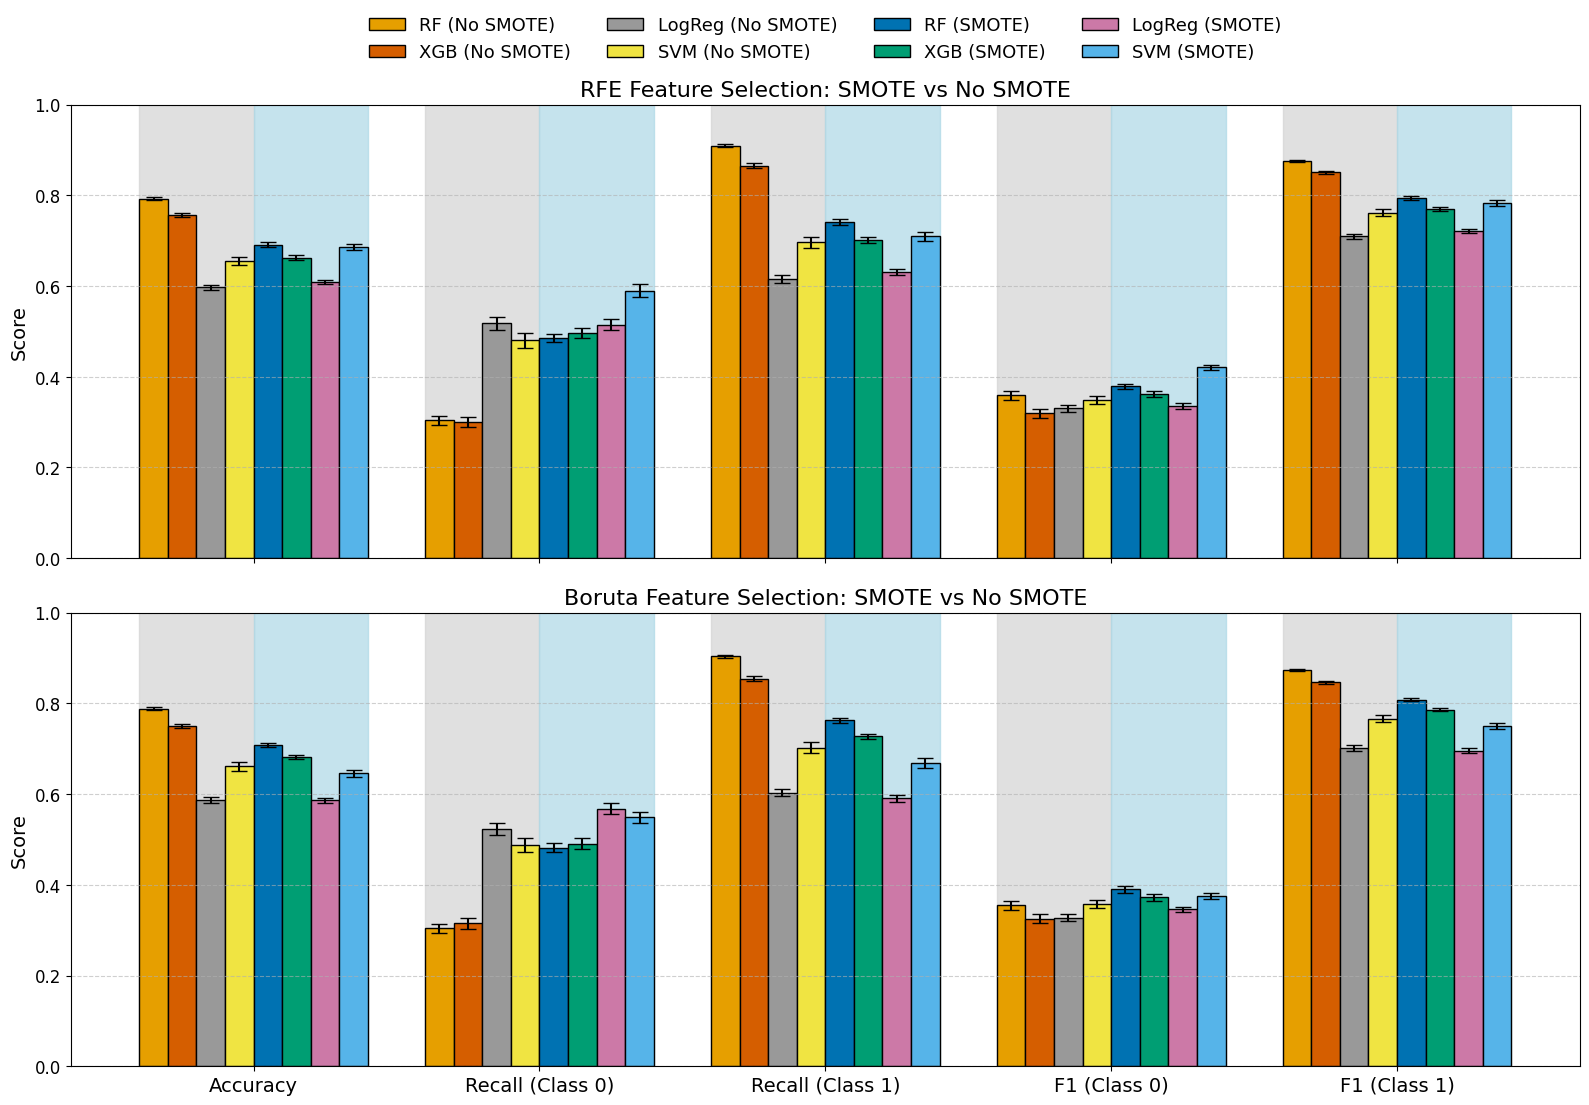

In [23]:
metrics = ["Accuracy", "Recall (Class 0)", "Recall (Class 1)", "F1 (Class 0)", "F1 (Class 1)"]
labels = [
    "RF (No SMOTE)", "XGB (No SMOTE)", "LogReg (No SMOTE)", "SVM (No SMOTE)",
    "RF (SMOTE)", "XGB (SMOTE)", "LogReg (SMOTE)", "SVM (SMOTE)"
]
colors = [
    "#E69F00", "#D55E00", "#999999", "#F0E442",  # No SMOTE
    "#0072B2", "#009E73", "#CC79A7", "#56B4E9"   # SMOTE
]

bar_sets_rfe = [
    (means_rf_rfe_nosmote, ci_rf_rfe_nosmote),
    (means_xgb_rfe_nosmote, ci_xgb_rfe_nosmote),
    (means_log_rfe_nosmote, ci_log_rfe_nosmote),
    (means_svm_rfe_nosmote, ci_svm_rfe_nosmote),
    (means_rf_rfe_smote, ci_rf_rfe_smote),
    (means_xgb_rfe_smote, ci_xgb_rfe_smote),
    (means_log_rfe_smote, ci_log_rfe_smote),
    (means_svm_rfe_smote, ci_svm_rfe_smote)
]


bar_sets_boruta = [
    (means_rf_boruta_nosmote, ci_rf_boruta_nosmote),
    (means_xgb_boruta_nosmote, ci_xgb_boruta_nosmote),
    (means_log_boruta_nosmote, ci_log_boruta_nosmote),
    (means_svm_boruta_nosmote, ci_svm_boruta_nosmote),
    (means_rf_boruta_smote, ci_rf_boruta_smote),
    (means_xgb_boruta_smote, ci_xgb_boruta_smote),
    (means_log_boruta_smote, ci_log_boruta_smote),
    (means_svm_boruta_smote, ci_svm_boruta_smote)
]


fig, axs = plt.subplots(2, 1, figsize=(16, 11), sharex=True, sharey=True)

plot_bootstrap_metrics_bars(
    bar_sets=bar_sets_rfe,
    metrics=metrics,
    labels=labels,
    colors=colors,
    title="RFE Feature Selection: SMOTE vs No SMOTE",
    ax=axs[0],
    legend=True
)

plot_bootstrap_metrics_bars(
    bar_sets=bar_sets_boruta,
    metrics=metrics,
    labels=labels,
    colors=colors,
    title="Boruta Feature Selection: SMOTE vs No SMOTE",
    ax=axs[1],
    legend=False 
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)
plt.savefig("../plots_extension/ML_plots/combined_rfe_boruta_smote_shaded.png", dpi=400)
plt.show()

## 4) SHAP Plots

We use SHAP (SHapley Additive exPlanations) to interpret model predictions and understand feature importance.

1. **Non-SMOTE Models**  
   - SHAP values are computed for models trained on imbalanced data  
   - Feature names are mapped to clean, human-readable labels

2. **SMOTE Models**  
   - Same SHAP analysis is repeated on models trained with SMOTE-balanced data  
   - Allows comparison of feature importance stability across sampling strategies

>  SHAP plots reveal which radiomic features most strongly influence malignancy predictions, under both balanced and imbalanced conditions.


1. Non-SMOTE dataset

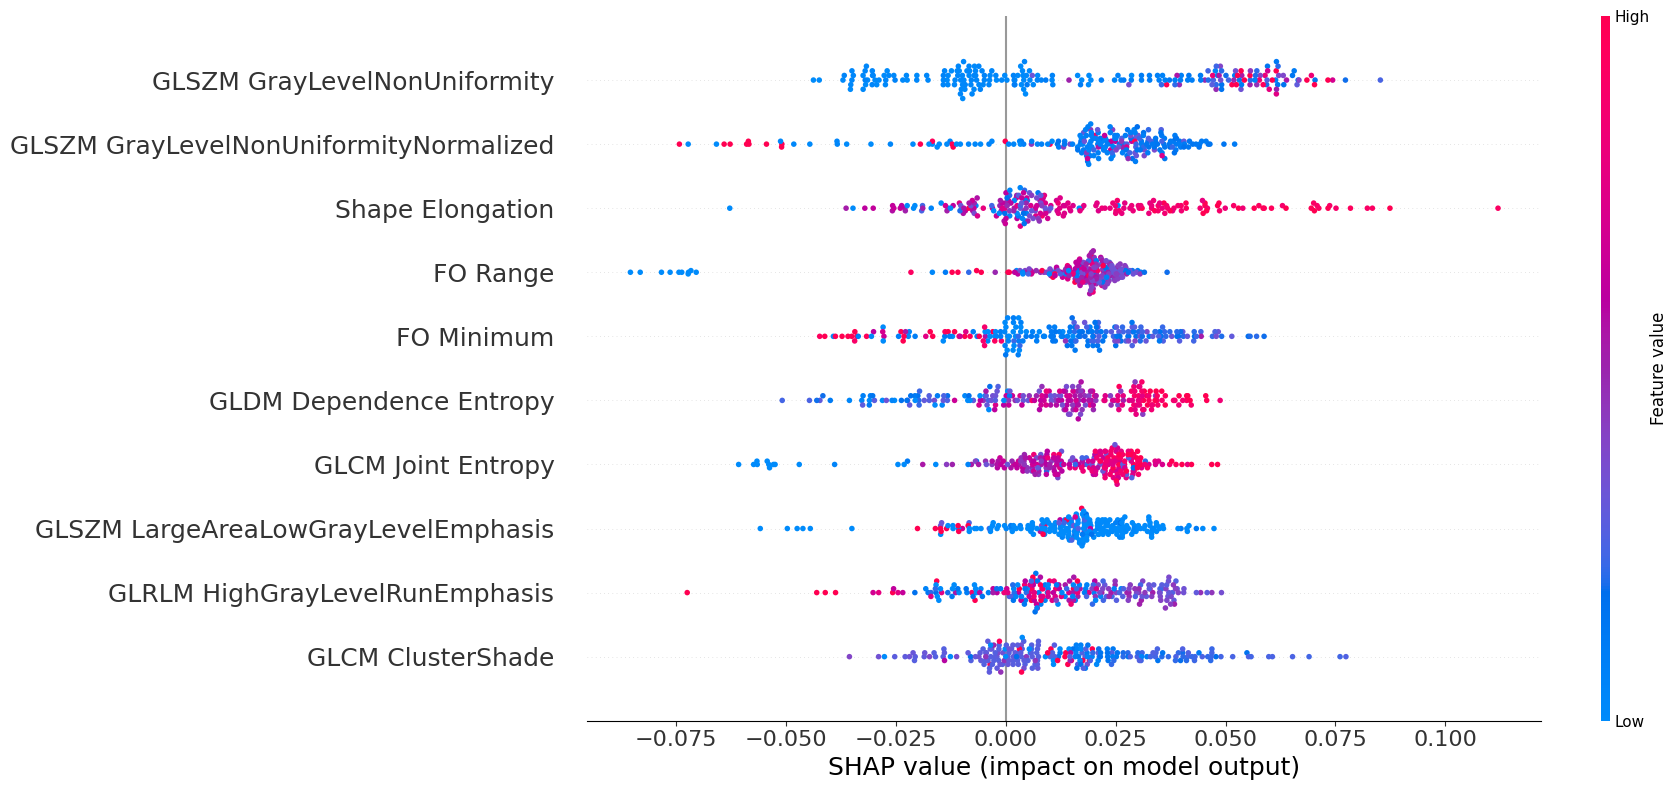

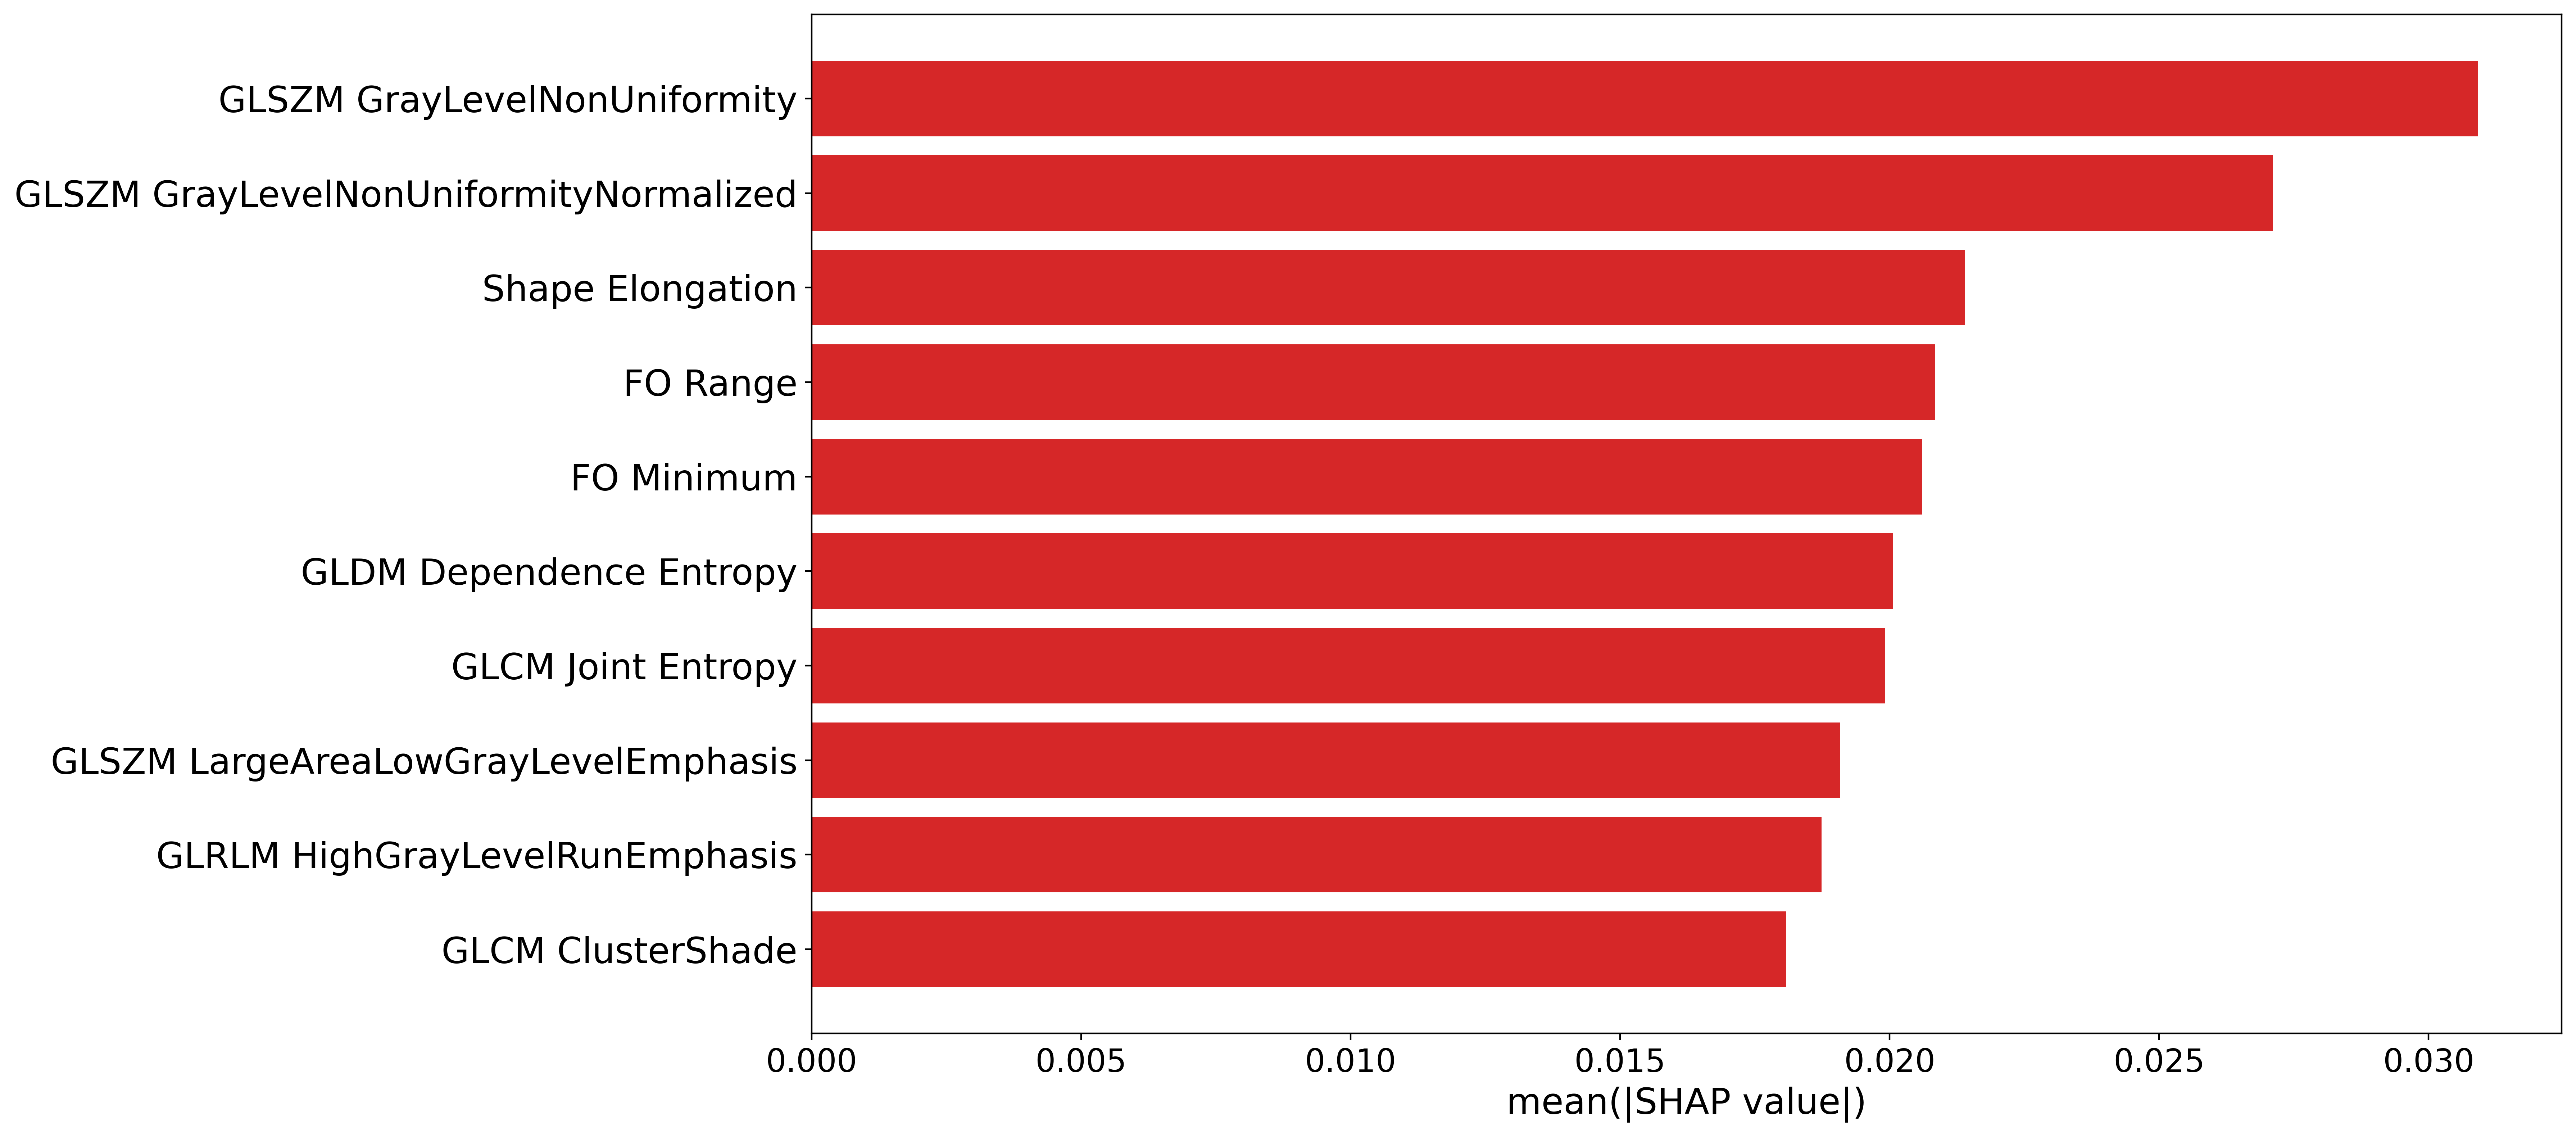

In [24]:
plot_shap_summary_and_bar(X_train, y_train, "full", get_friendly_feature_names)

2. SMOTE Dataset

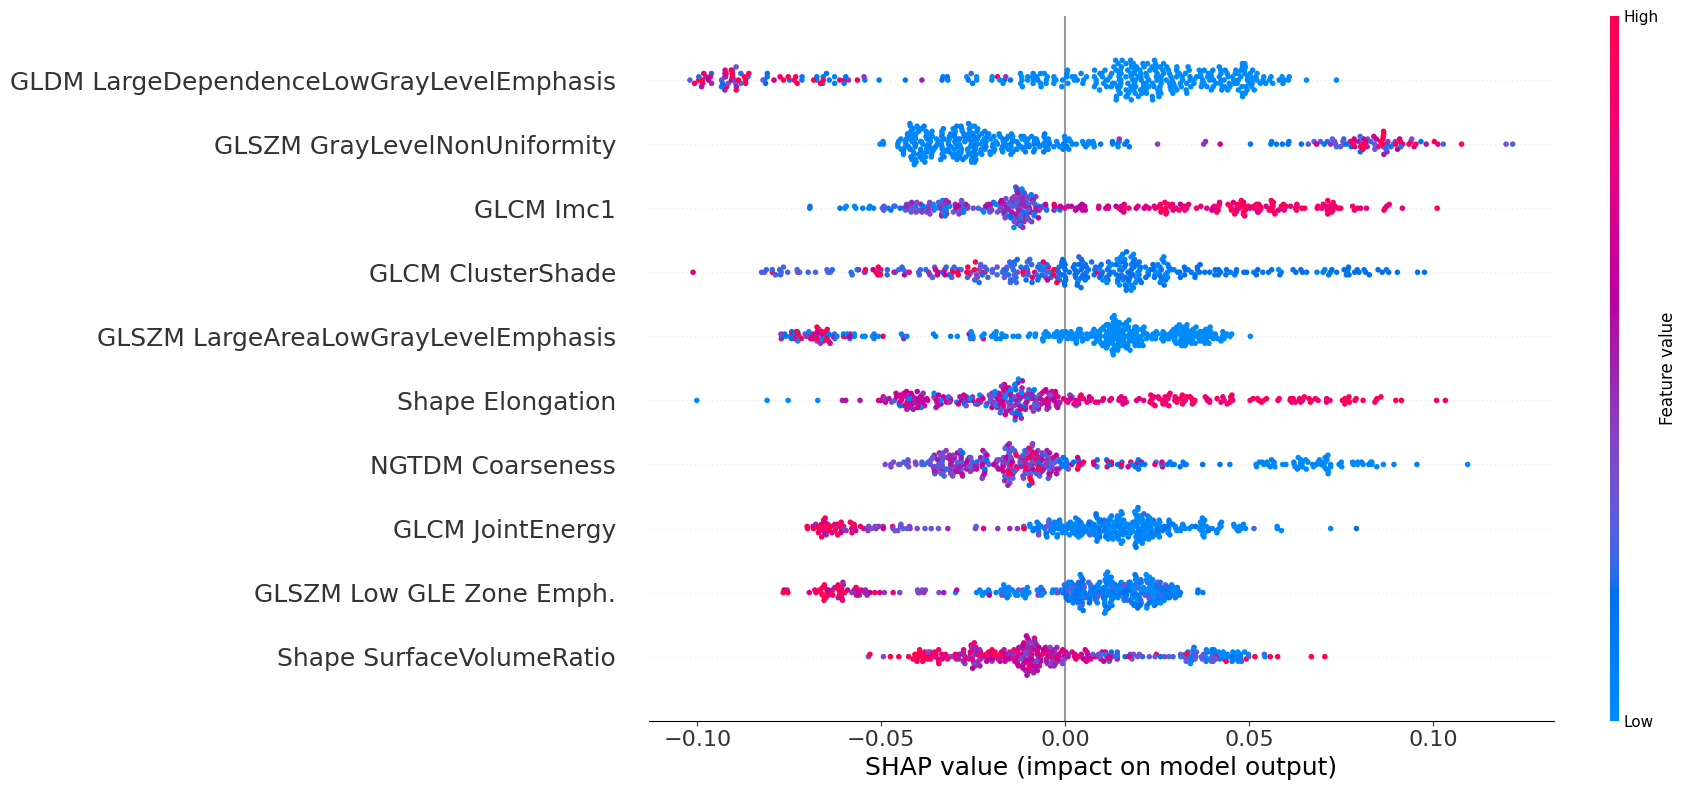

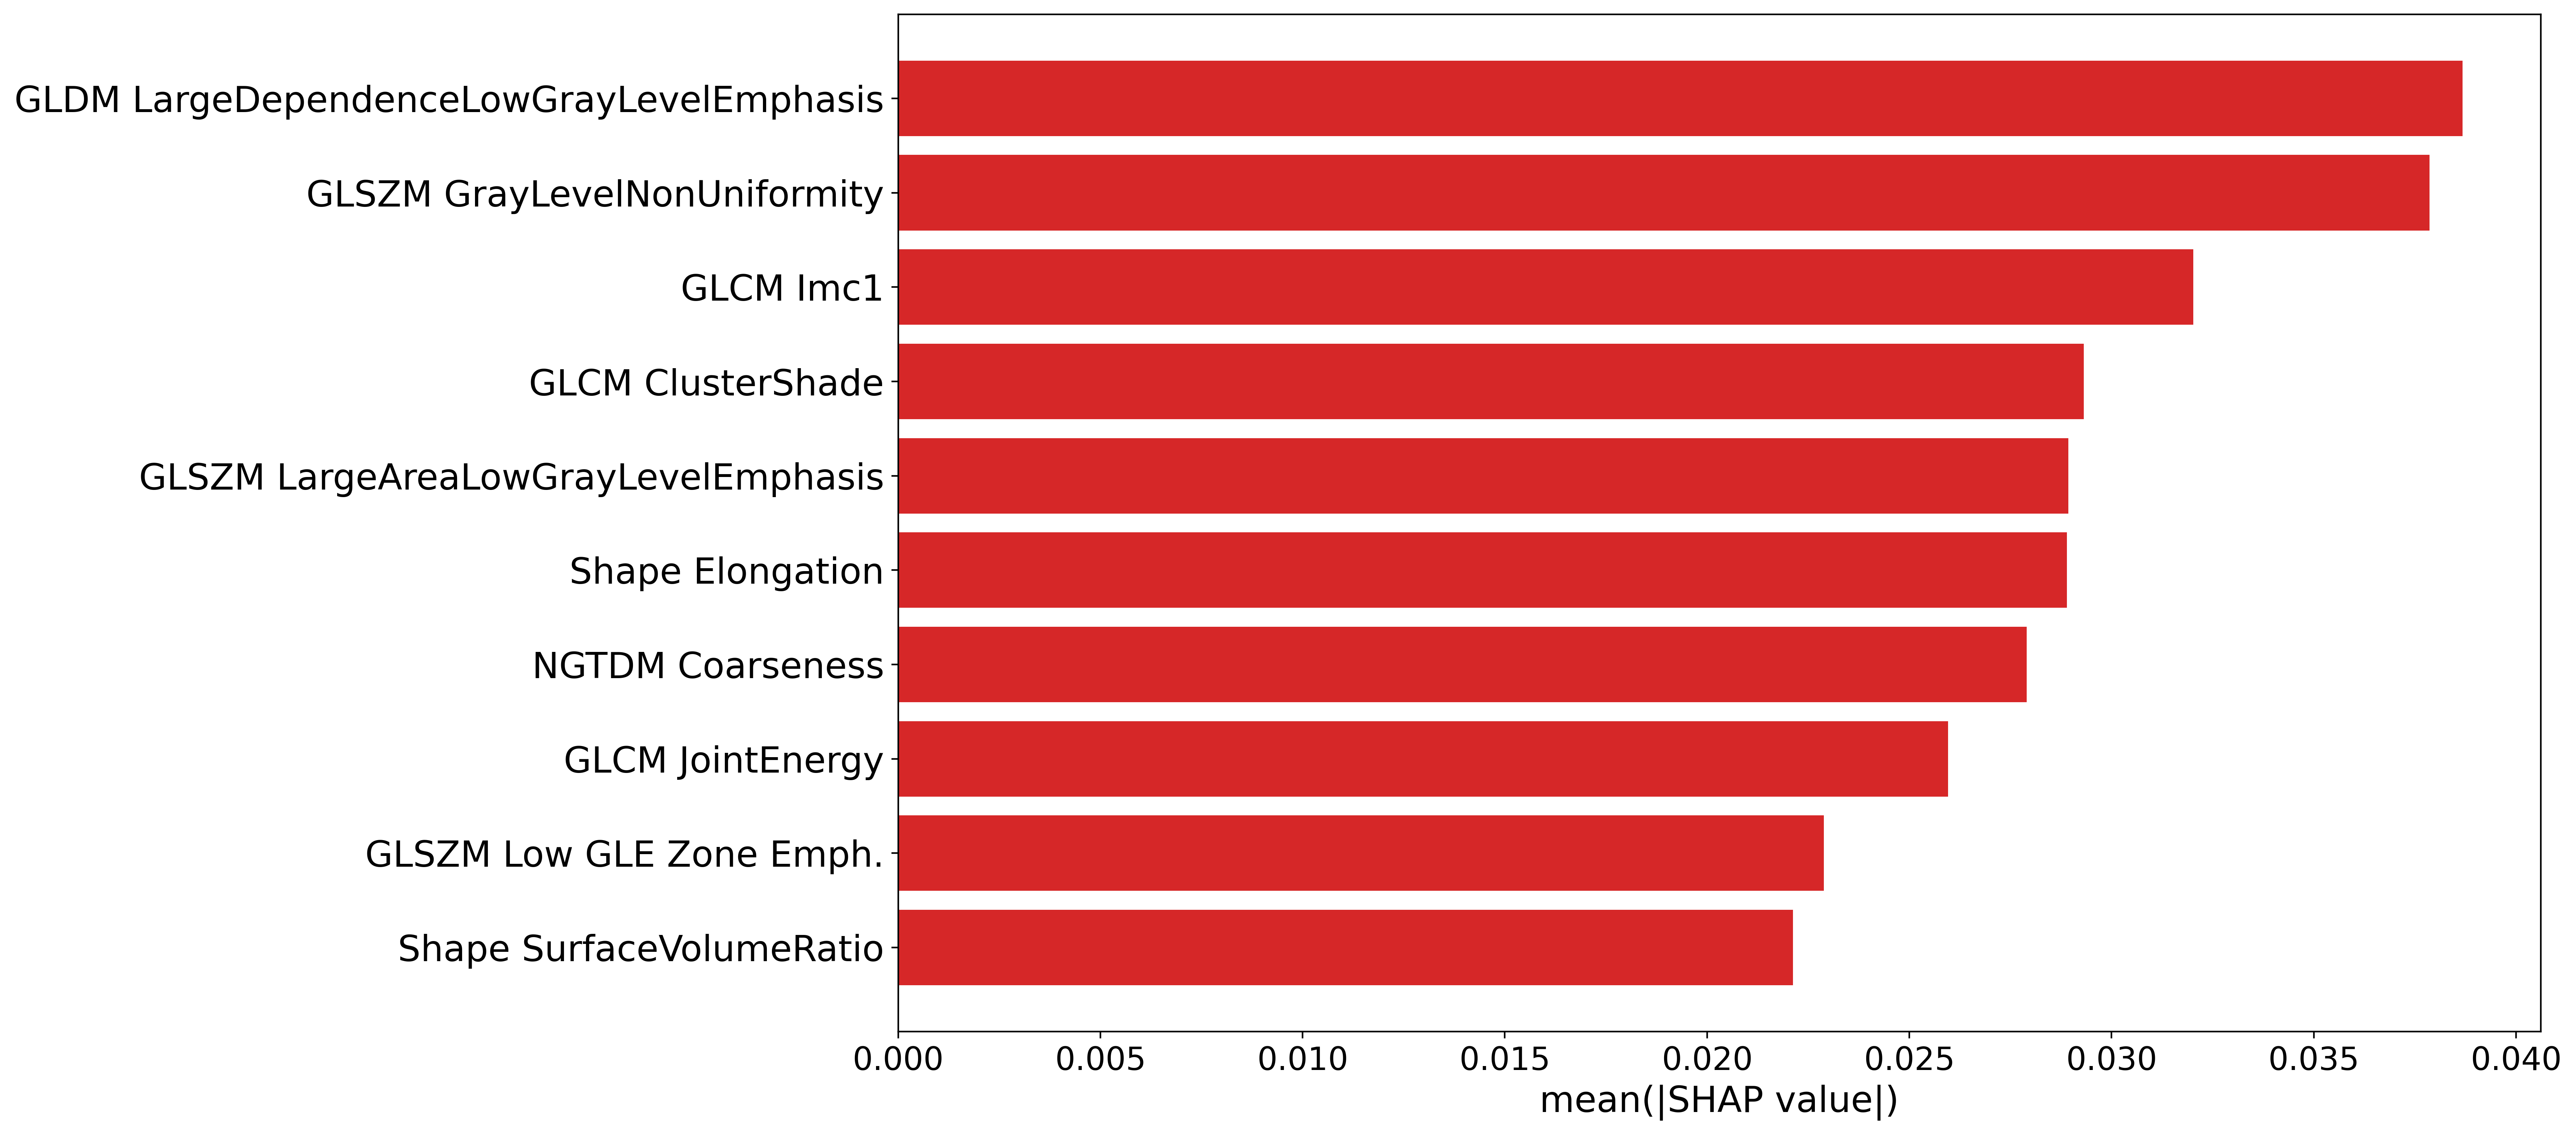

In [25]:
plot_shap_summary_and_bar(X_train_smote, y_train_smote, "SMOTE", get_friendly_feature_names)

## 5) Supplementary Plots

This section includes additional visualisations to support and validate the main analysis:

- **Feature Selection Overlap**  
  Venn diagram comparing features selected by RFE and Boruta

- **SHAP Consistency Analysis**  
  Box plots showing SHAP importance ranks across 100 random seeds, highlighting the stability of top features for both RFE and Boruta sets

> These plots help assess the agreement between feature selectors and the robustness of SHAP-based interpretations.


Feature selection overlap

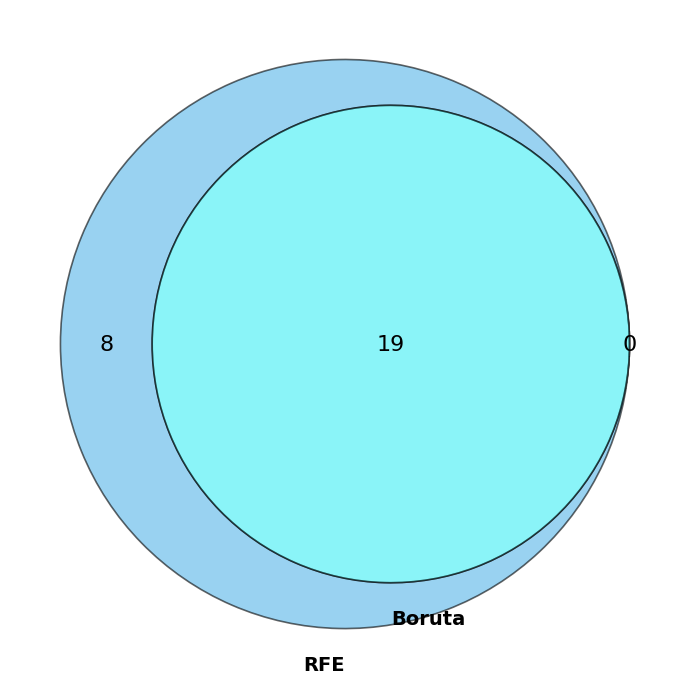

In [26]:
# Plot overlap between RFE and Boruta selected features
plot_feature_selection_venn(
    rfe_features=rfe_selected,
    boruta_features=boruta_selected,
    save_path="../plots_extension/feature_selection_plots/venn_rfe_boruta_improved.png"
)

SHAP consistency box plot

/Users/saamnazem/mphil_project/sn665/src/Extension.py:858: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


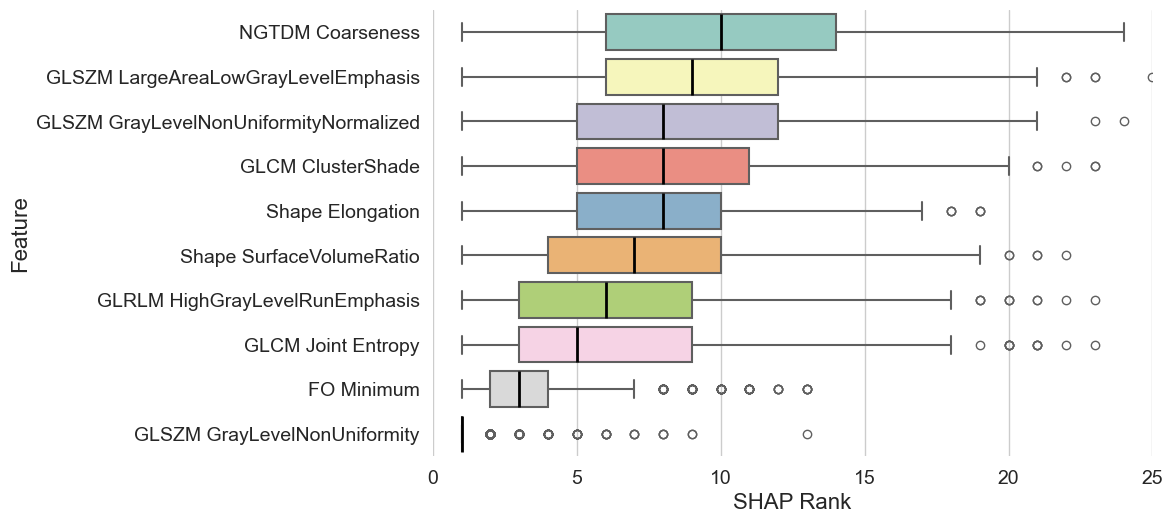

In [27]:
# Get SHAP rank stability for top 10 features (No SMOTE)
shap_ranks_top10_nosmote = compute_shap_rank_stability(
    X=X_train,
    y=y_train,
    friendly_names=get_friendly_feature_names(X_train.columns),
    n_seeds=1000,
    top_k=10
)

# Plot SHAP rank boxplot (No SMOTE)
plot_shap_rank_stability(
    shap_ranks_top10_nosmote,
    save_path="../plots_extension/shap_plots/shap_rank_stability_horizontal_nosmote.png",
    xlim=(0, 25)
)

SMOTE version

/Users/saamnazem/mphil_project/sn665/src/Extension.py:858: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


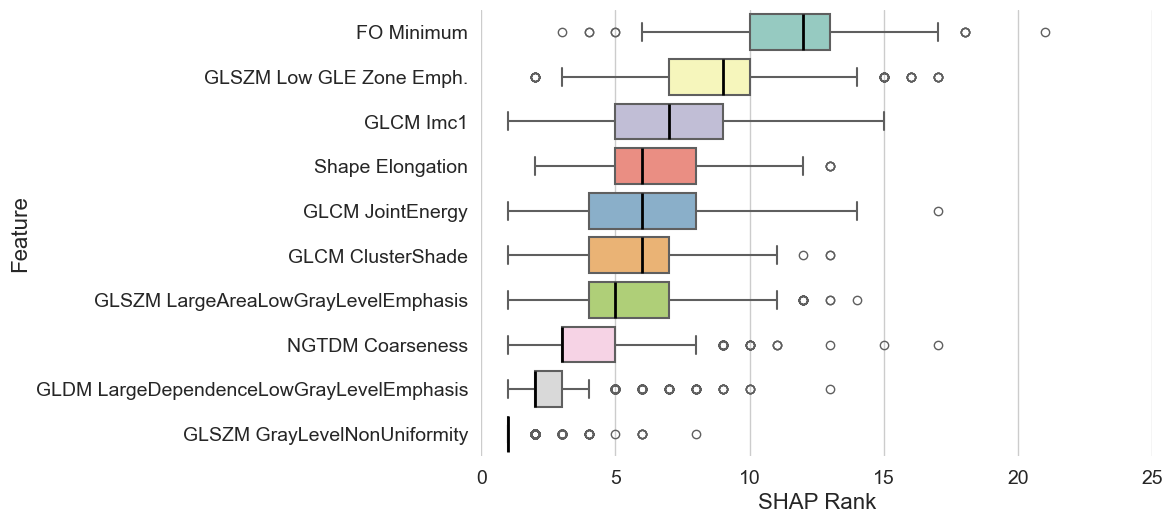

In [28]:
# Get SHAP rank stability for top 10 features (SMOTE)
shap_ranks_top10_smote = compute_shap_rank_stability(
    X=X_train_smote,
    y=y_train_smote,
    friendly_names=get_friendly_feature_names(X_train_smote.columns),
    n_seeds=1000,
    top_k=10
)

# Plot SHAP rank boxplot (SMOTE)
plot_shap_rank_stability(
    shap_ranks_top10_smote,
    save_path="../plots_extension/shap_plots/shap_rank_stability_horizontal_smote.png",
    xlim=(0, 25)
)